# Библиотеки

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
import seaborn as sns

# Описание датасета

Attribute Information:

1) ID number
2) Diagnosis (M = malignant, B = benign)

Ten real-valued features are computed for each cell nucleus:

a) radius (mean of distances from center to points on the perimeter)

b) texture (standard deviation of gray-scale values)

c) perimeter

d) area

e) smoothness (local variation in radius lengths)

f) compactness (perimeter^2 / area - 1.0)

g) concavity (severity of concave portions of the contour)

h) concave points (number of concave portions of the contour)

i) symmetry

j) fractal dimension ("coastline approximation" - 1)

1) ID
2) Диагноз(M = злокачественная, B = доброкачественная)

10 числовых переменных рассчитаны для кажлого ядра клетки:

a) радиус (среднее расстояний от центра до точек, лежащих на перимитере)

b) текстура (стандартное отклонение от значений чёрно-белой картинки)

c) периметр

d) площадь

e) гладкость (локальная вариация длинн радиуса)

f) компактность (периметр^2 / площадь - 1.0)

g) выпуклость (сила выпуклости выпуклых частей контура)

h) точки выпуклости (кол-во)

i) симметрия

j) фрактальная размерность (dim)

# Первый взгляд на данные

In [3]:
df = pd.read_csv('data_cancer.csv')
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

Хорошо, что у нас все в числах, но хочетлось бы целевую переменную привести к виду {0,1} для бинарной классификации, удалить последний столбец, так как в нем нет ничего кроме пропусков

In [5]:
df = df.drop(columns = 'Unnamed: 32')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
df.diagnosis = df.diagnosis.replace({'M': 1, 'B': 0})
df.head()

/tmp/ipykernel_1530/1113126860.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.diagnosis = df.diagnosis.replace({'M': 1, 'B': 0})


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Посмотрим есть ли дубликаты/дубликаты по id

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.duplicated(subset=['id']).sum()

np.int64(0)

И там и там дубликатов нет, то есть у нас 569 уникальных людей

Удалим id

In [9]:
df = df.drop(columns = 'id')
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Посмотрим на корреляцию признаков

<Axes: >

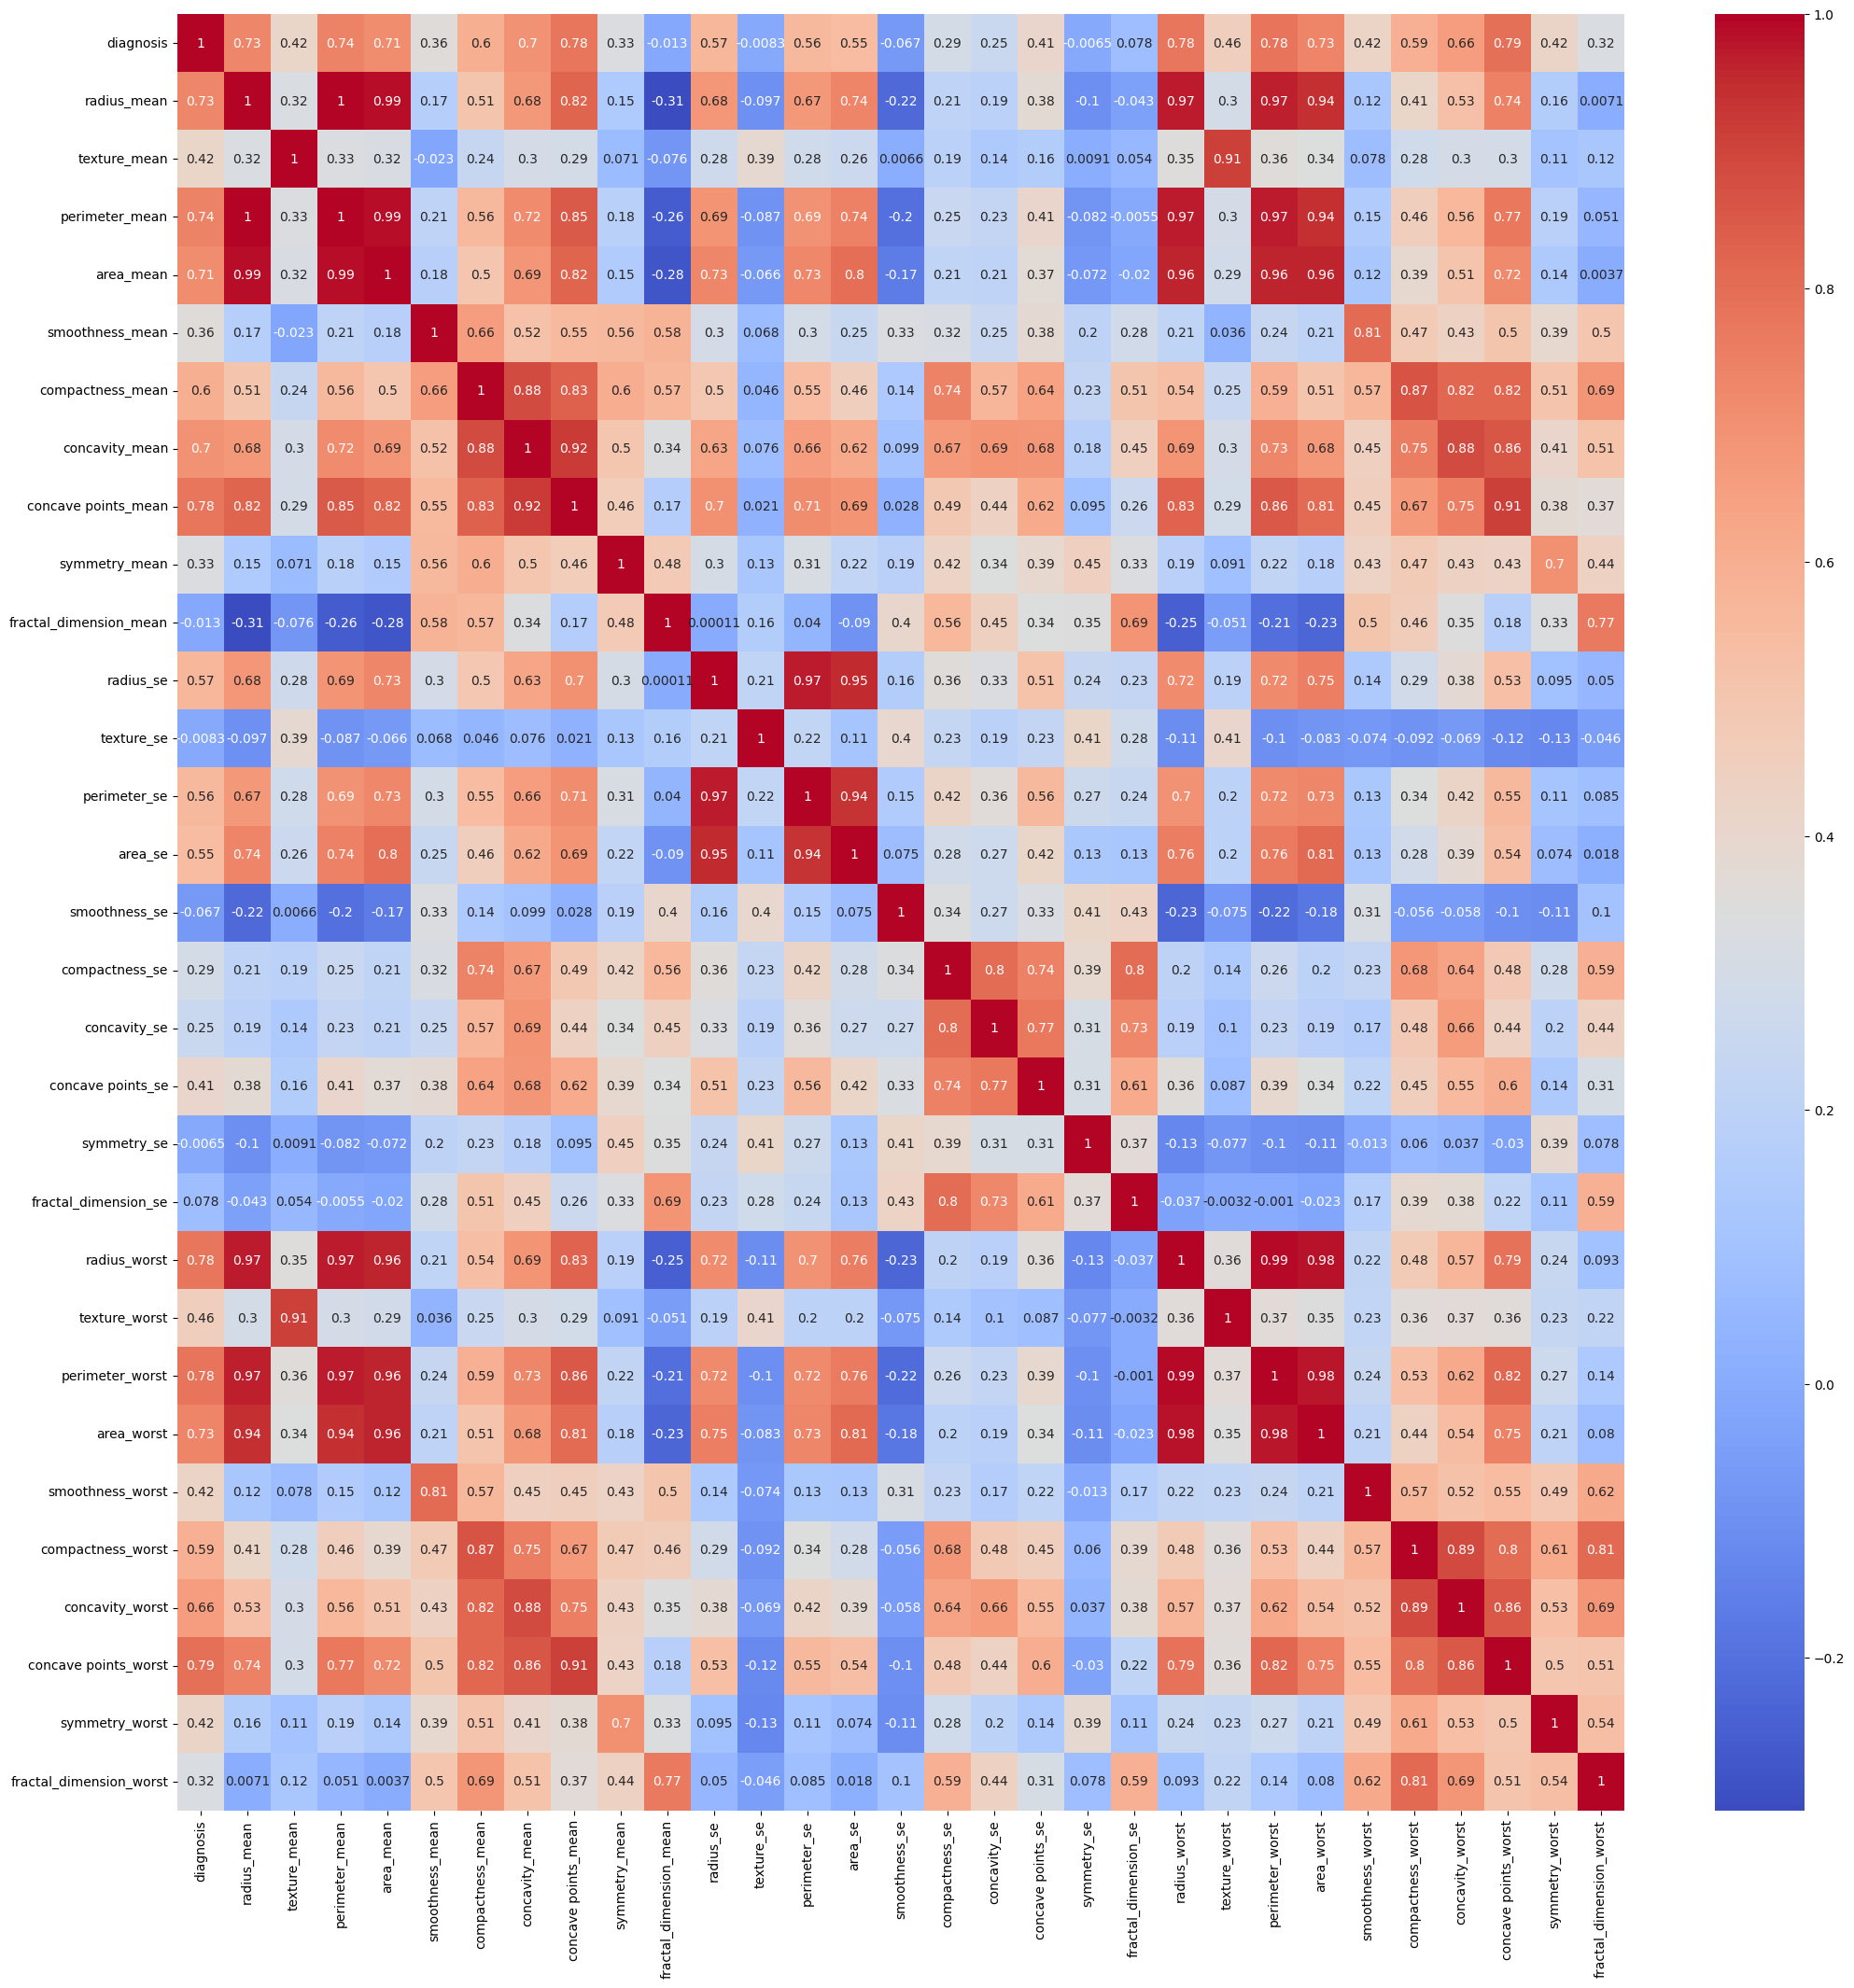

In [10]:
plt.figure(figsize=(25,25))

df_corr = df.corr(numeric_only = True)

sns.heatmap(df_corr, cbar=True, cmap='coolwarm', annot=True, fmt=".2g")

Поглядим на значение целевой переменной

In [11]:
print(f"Размер нулевого класса: {sum(df.diagnosis == 0)}")
print(f"Размер первого класса:  {sum(df.diagnosis == 1)}")
print(f"Доля первого класса:   {sum(df.diagnosis == 1) / len(df.diagnosis)}")

Размер нулевого класса: 357
Размер первого класса:  212
Доля первого класса:   0.37258347978910367


Плюс минус нормальное разделение, сильного дизбаланса классов не наблюдается

Вернемся к матрице корреляций, видно что есть много признаков коррелирущих друг с другом и с тцелевой переменной, так что предлагаю сделать PCA, чтобы уменьшить количество признаков, в качестве мы не должны сильно потерять, так как у нас есть сильные линейные зависимости между признаками

Но для начала нужно разделить выборку на train и test, воспользуемся  Stratified разделением, чтобы сохранить баланс классов, на том же уровне

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X = df.drop(columns='diagnosis')
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12, stratify=y)

Стандартизируем признаки

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)

StandardScaler()

In [15]:
X_train_normed = scaler.transform(X_train)
X_test_normed = scaler.transform(X_test)

In [16]:
X_train.shape

(455, 30)

Оставим из 30ти, 20 признаков

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 20)

pca.fit(X_train_normed)

PCA(n_components=20)

In [18]:
X_train_pca = pca.transform(X_train_normed)
X_test_pca = pca.transform(X_test_normed)

In [19]:
X_train_pca_df = pd.DataFrame(X_train_pca)

<Axes: >

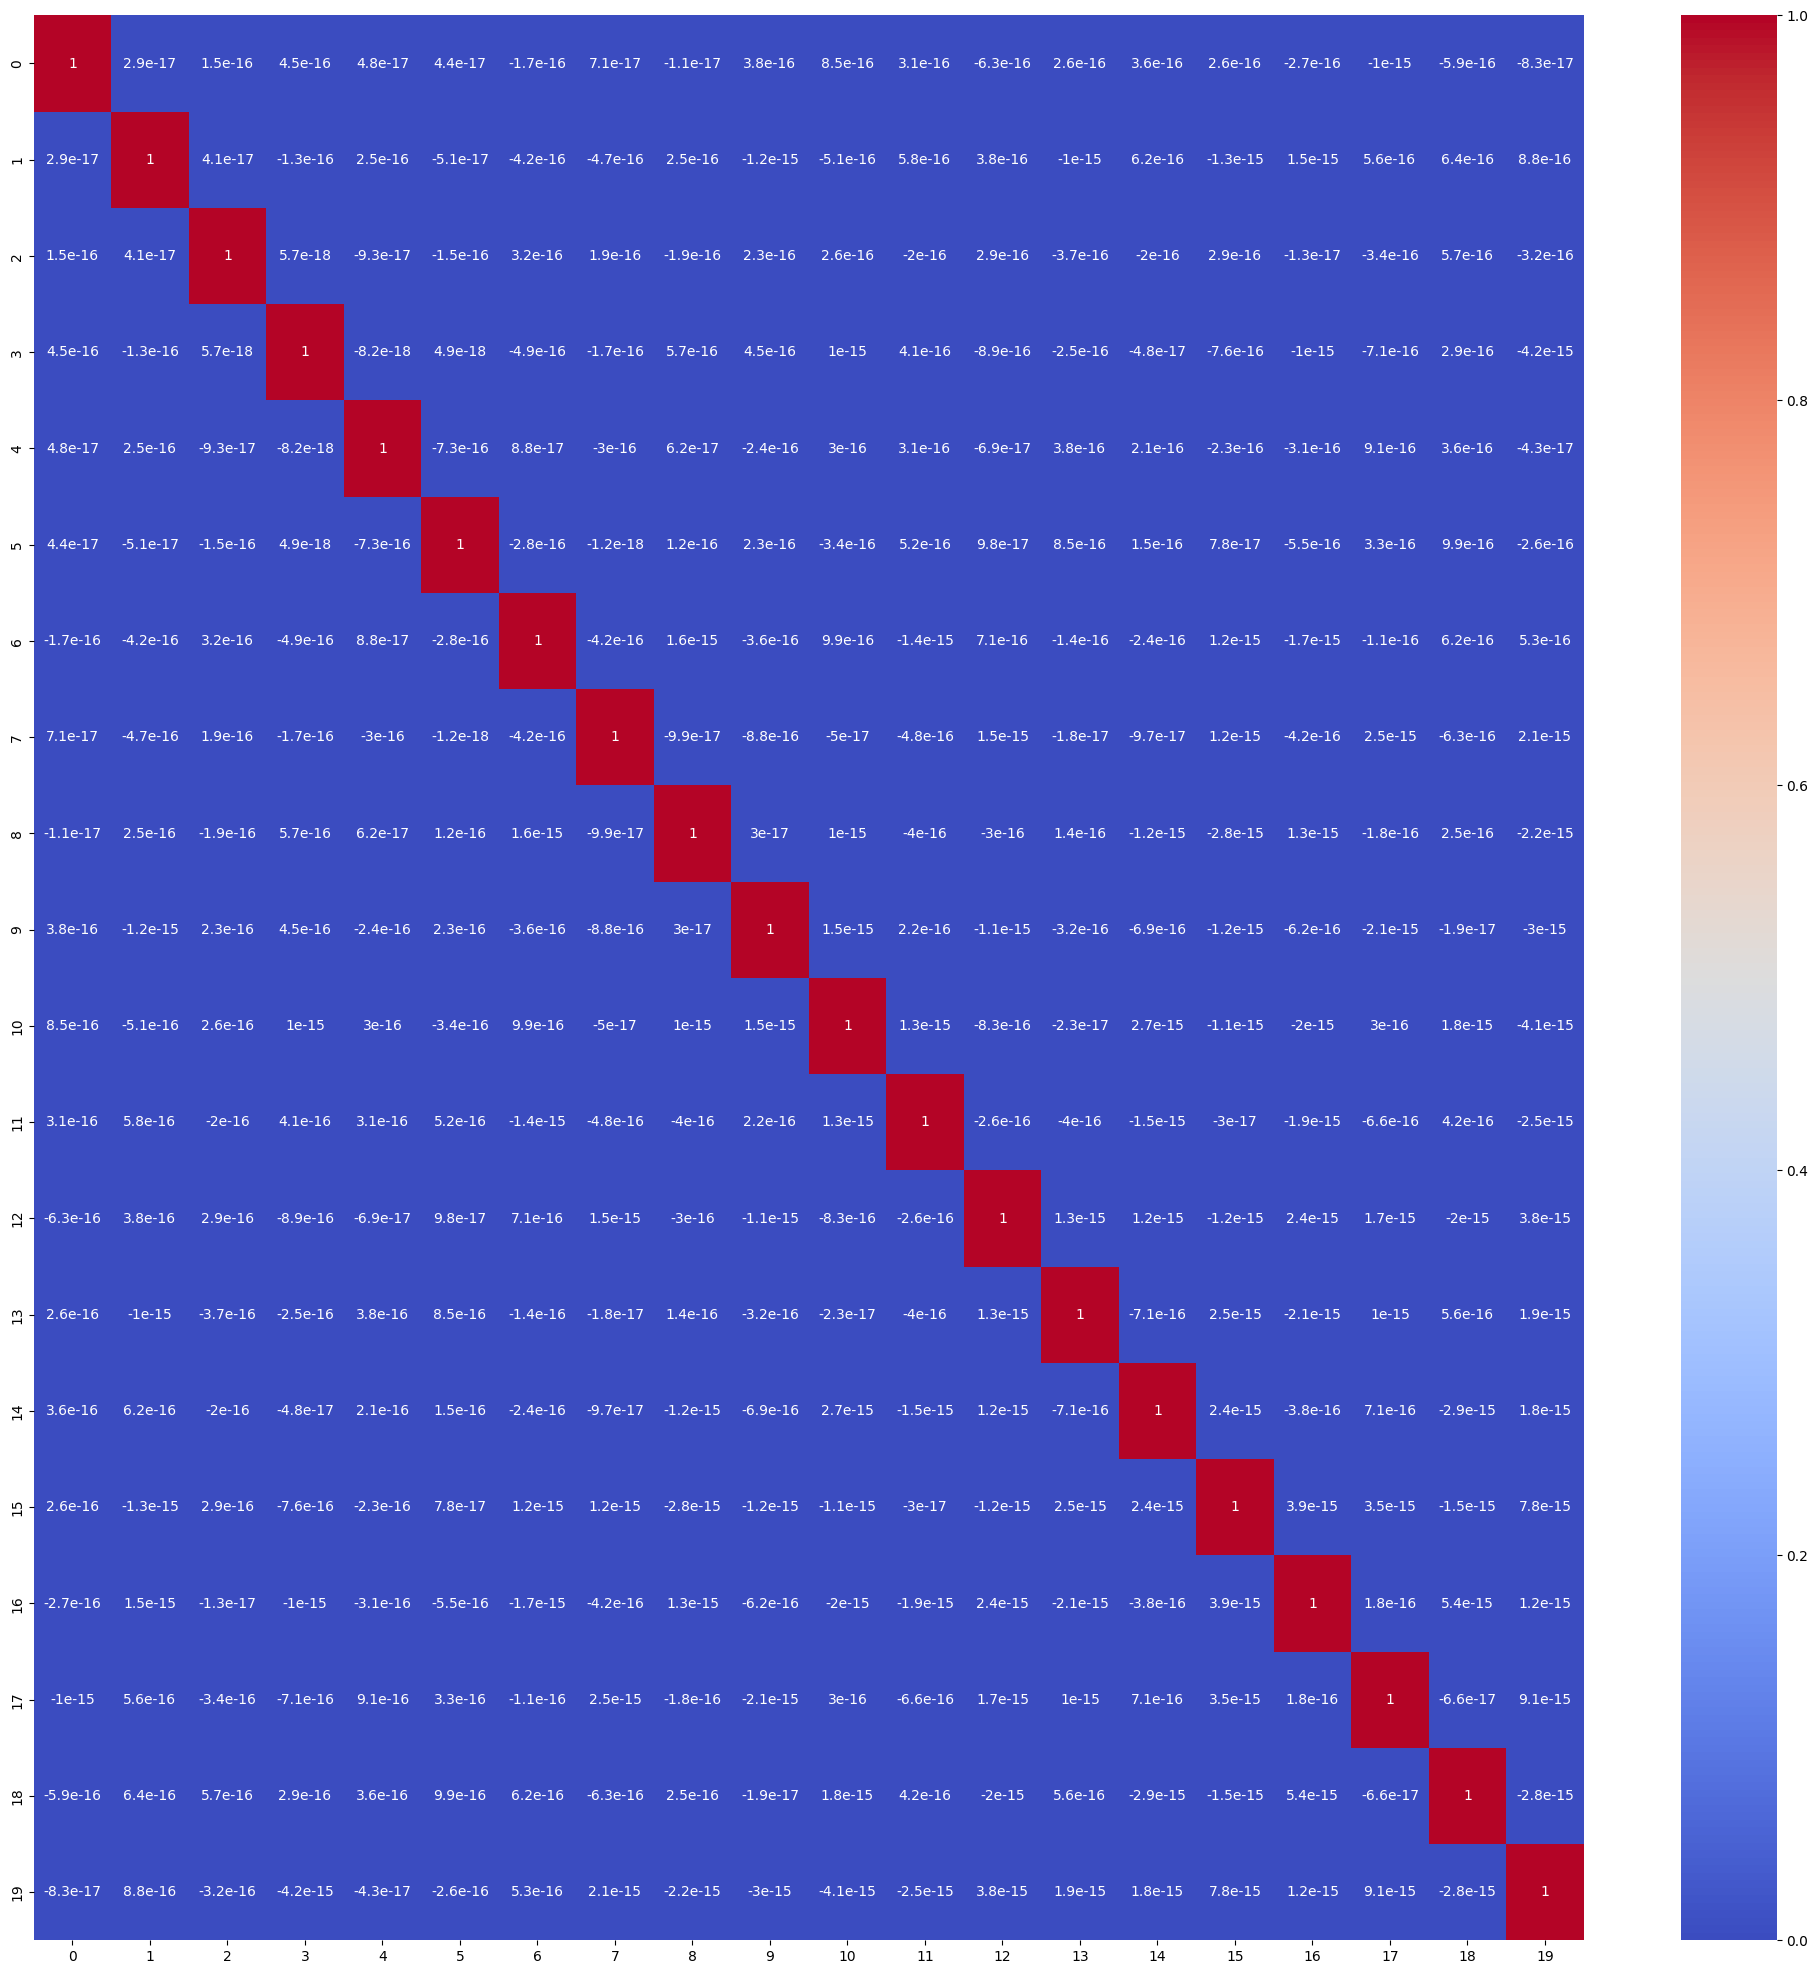

In [20]:
plt.figure(figsize=(25,25))

X_train_pca_corr = X_train_pca_df.corr(numeric_only = True)

sns.heatmap(X_train_pca_corr, cbar=True, cmap='coolwarm', annot=True, fmt=".2g")

# Полносвязная нейронная сеть

In [74]:
import joblib

In [21]:
# установим последнюю версию wandb
!pip install -q --upgrade wandb

In [57]:
import os
import wandb # для логирования

import numpy as np
import random
from tqdm import *

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim # для оптимизаторов
from torchvision import datasets # для данных
import torchvision.transforms as transforms # для преобразований тензоров

import matplotlib.pyplot as plt

In [50]:
# Зафиксируем seed для воспроизводимости

def seed_everything(seed):
    random.seed(seed) # фиксируем генератор случайных чисел
    os.environ['PYTHONHASHSEED'] = str(seed) # фиксируем заполнения хешей
    np.random.seed(seed) # фиксируем генератор случайных чисел numpy
    torch.manual_seed(seed) # фиксируем генератор случайных чисел pytorch
    torch.cuda.manual_seed(seed) # фиксируем генератор случайных чисел для GPU
    #torch.backends.cudnn.deterministic = True # выбираем только детерминированные алгоритмы (для сверток)
    #torch.backends.cudnn.benchmark = False # фиксируем алгоритм вычисления сверток

In [51]:
class CFG:

# Задаем параметры нашего эксперимента

  api = ""# вписать свой API Wandb
  project = "GP5"# вписать название эксперимента, который предварительно надо создать в Wandb
  entity = "polinaabo9-hse-university"# ввести свой логин
  num_epochs = 10 # количество эпох
  train_batch_size = 64 # размер батча обучающей выборки
  test_batch_size = 512 # размер батча тестовой выборки
  num_workers = 2 # количество активных процессов на загрузку данных
  lr = 0.001 # learning_rate
  seed = 2022 # для функции воспроизводимости
  wandb = True # флаг использования Wandb

In [52]:
# функция перевода класса конфигурации в словарь

def class2dict(f):
  return dict((name, getattr(f, name)) for name in dir(f) if not name.startswith('__'))

## Подготовка данных для PyTorch

In [53]:
train_data = torch.utils.data.TensorDataset(
    torch.tensor(X_train_pca, dtype=torch.float32),
    torch.tensor(y_train.to_numpy(), dtype=torch.long)
)

test_data = torch.utils.data.TensorDataset(
    torch.tensor(X_test_pca, dtype=torch.float32),
    torch.tensor(y_test.to_numpy(), dtype=torch.long)
)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=CFG.train_batch_size,
                                          shuffle=True, num_workers=CFG.num_workers, pin_memory=True)

test_loader = torch.utils.data.DataLoader(test_data, batch_size=CFG.test_batch_size,
                                         shuffle=False, num_workers=CFG.num_workers, pin_memory=True)

In [54]:
examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)

print(example_data.shape)
print(example_targets.shape)
print(example_targets[:10])

torch.Size([114, 20])
torch.Size([114])
tensor([0, 0, 1, 0, 0, 0, 1, 1, 1, 0])


## Полносвязная нейронная сеть


In [55]:
class Cancer_Net(nn.Module):
    def __init__(self):
        super(Cancer_Net, self).__init__()

        hidden_1 = 200
        hidden_2 = 150

        self.fc1 = nn.Linear(20, hidden_1)
        self.fc2 = nn.Linear(hidden_1, hidden_2)
        self.fc3 = nn.Linear(hidden_2, 2)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [59]:
model = Cancer_Net()
print(model)

Cancer_Net(
  (fc1): Linear(in_features=20, out_features=200, bias=True)
  (fc2): Linear(in_features=200, out_features=150, bias=True)
  (fc3): Linear(in_features=150, out_features=2, bias=True)
)


## Функция потерь и оптимизатор для SGD

In [76]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

## Функции обучения и проверки


Сохранять параметры модели будем через torch.save https://docs.pytorch.org/docs/2.12/generated/torch.save.html и будем сохранять данные в  wandb.Artifact https://docs.wandb.ai/models/artifacts/construct-an-artifact

In [61]:
def train(model, device, train_loader, optimizer, criterion, epoch, WANDB):
    model.train()
    train_loss = 0
    correct = 0

    n_ex = len(train_loader)

    for batch_idx, (data, target) in tqdm(enumerate(train_loader), total=n_ex):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()

        output = model(data)
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()

        train_loss = criterion(output, target)
        train_loss.backward()
        optimizer.step()

    tqdm.write('\nTrain set: Average loss: {:.4f}, Accuracy: {:.0f}%'.format(
        train_loss, 100. * correct / len(train_loader.dataset)))

    if WANDB:
        wandb.log({'epoch': epoch,
                   'train_loss': train_loss,
                   'train_accuracy': correct / len(train_loader.dataset)})

In [62]:
def test(model, device, test_loader, criterion, epoch, WANDB):
    model.eval()
    test_loss = 0
    correct = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)

            output = model(data)
            test_loss = criterion(output, target)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()


    tqdm.write('Test set: Average loss: {:.4f}, Accuracy: {:.0f}%'.format(
        test_loss, 100. * correct / len(test_loader.dataset)))

    if WANDB:
        wandb.log({'epoch': epoch,
                   'test_loss': test_loss,
                   'test_accuracy': correct / len(test_loader.dataset)})

In [77]:
def main(model):
    if CFG.wandb:
        wandb.login(key=CFG.api)
        wandb.init(
          project=CFG.project,
          entity=CFG.entity,
          config={
              'model': 'Cancer_Net',
              'input_size': 20,
              'hidden_1': 200,
              'hidden_2': 150,
              'output_size': 2,
              'optimizer': 'SGD',
              'learning_rate': 0.001,
              'loss': 'CrossEntropyLoss',
              'batch_size': CFG.train_batch_size,
              'epochs': CFG.num_epochs,
              'seed': CFG.seed,
              'pca_components': 20,
              'layer_type': 'nn.Linear',
              'activation': 'ReLU',
              'architecture': 'Linear(20, 200) -> ReLU -> Linear(200, 150) -> ReLU -> Linear(150, 2)'
          }
)

    use_cuda = torch.cuda.is_available()

    seed_everything(CFG.seed)

    device = torch.device("cuda" if use_cuda else "cpu")

    if CFG.wandb:
        wandb.watch(model, log='all')

    for epoch in range(1, CFG.num_epochs + 1):
        print('\nEpoch:', epoch)
        train(model, device, train_loader, optimizer, criterion, epoch, CFG.wandb)
        test(model, device, test_loader, criterion, epoch, CFG.wandb)

    if CFG.wandb:
        torch.save({
            'model_state_dict': model.state_dict(),
            'input_size': 20,
            'hidden_1': 200,
            'hidden_2': 150,
            'output_size': 2,
            'classes': [0, 1]
        }, 'cancer_net_sgd.pth')

        model_artifact = wandb.Artifact(
            name='cancer-net-sgd',
            type='model',
            metadata={
                'architecture': 'Linear(20, 200) -> ReLU -> Linear(200, 150) -> ReLU -> Linear(150, 2)',
                'optimizer': 'SGD',
                'learning_rate': 0.001,
                'loss': 'CrossEntropyLoss'
            }
        )

        model_artifact.add_file('cancer_net_sgd.pth')
        wandb.run.log_artifact(model_artifact)

        wandb.finish()

    print('Training is ended!')

## Обучение с SGD

In [78]:
main(model)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc



Epoch: 1


100%|██████████| 8/8 [00:00<00:00, 83.57it/s]


Train set: Average loss: 0.0062, Accuracy: 100%


Test set: Average loss: 0.0551, Accuracy: 97%

Epoch: 2


...

100%|██████████| 8/8 [00:00<00:00, 105.48it/s]


Train set: Average loss: 0.0044, Accuracy: 100%


Test set: Average loss: 0.0548, Accuracy: 97%


epoch,▁▁▂▂▃▃▃▃▄▄▅▅▆▆▆▆▇▇██
test_accuracy,▁▁▁▁▁▁▁▁▁▁
test_loss,▆▇▅▄█▆▅▃▂▁
train_accuracy,▁▁▁▁▁▁▁▁▁▁
train_loss,▂█▁▁█▂▂▁▁▂
epoch,10
test_accuracy,0.97368
test_loss,0.05482
train_accuracy,0.9978
train_loss,0.00435


Training is ended!


## Обучение с Adam

In [79]:
def main(model):
    if CFG.wandb:
        wandb.login(key=CFG.api)
        wandb.init(
          project=CFG.project,
          entity=CFG.entity,
          config={
              'model': 'Cancer_Net',
              'input_size': 20,
              'hidden_1': 200,
              'hidden_2': 150,
              'output_size': 2,
              'optimizer': 'Adam',
              'learning_rate': 0.001,
              'loss': 'CrossEntropyLoss',
              'batch_size': CFG.train_batch_size,
              'epochs': CFG.num_epochs,
              'seed': CFG.seed,
              'pca_components': 20,
              'layer_type': 'nn.Linear',
              'activation': 'ReLU',
              'architecture': 'Linear(20, 200) -> ReLU -> Linear(200, 150) -> ReLU -> Linear(150, 2)'
          }
)

    use_cuda = torch.cuda.is_available()

    seed_everything(CFG.seed)

    device = torch.device("cuda" if use_cuda else "cpu")

    if CFG.wandb:
        wandb.watch(model, log='all')

    for epoch in range(1, CFG.num_epochs + 1):
        print('\nEpoch:', epoch)
        train(model, device, train_loader, optimizer, criterion, epoch, CFG.wandb)
        test(model, device, test_loader, criterion, epoch, CFG.wandb)

    if CFG.wandb:
        torch.save({
            'model_state_dict': model.state_dict(),
            'input_size': 20,
            'hidden_1': 200,
            'hidden_2': 150,
            'output_size': 2,
            'classes': [0, 1]
        }, 'cancer_net_sgd.pth')

        model_artifact = wandb.Artifact(
            name='cancer-net-sgd',
            type='model',
            metadata={
                'architecture': 'Linear(20, 200) -> ReLU -> Linear(200, 150) -> ReLU -> Linear(150, 2)',
                'optimizer': 'Adam',
                'learning_rate': 0.001,
                'loss': 'CrossEntropyLoss'
            }
        )

        model_artifact.add_file('cancer_net_sgd.pth')
        wandb.run.log_artifact(model_artifact)

        wandb.finish()

    print('Training is ended!')

In [80]:
optimizer = torch.optim.Adam(model.parameters(), lr=CFG.lr)

main(model)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc



Epoch: 1


100%|██████████| 8/8 [00:00<00:00, 93.96it/s]


Train set: Average loss: 0.0050, Accuracy: 100%


Test set: Average loss: 0.0524, Accuracy: 98%

Epoch: 2


...

100%|██████████| 8/8 [00:00<00:00, 102.21it/s]


Train set: Average loss: 0.0002, Accuracy: 100%


Test set: Average loss: 0.0728, Accuracy: 97%


epoch,▁▁▂▂▃▃▃▃▄▄▅▅▆▆▆▆▇▇██
test_accuracy,█▁▁▁▁▁▁▁▁▁
test_loss,▁▄▅▂▂█▇▇▆▆
train_accuracy,▁▁████████
train_loss,▂█▁▁▅▁▁▁▁▁
epoch,10
test_accuracy,0.97368
test_loss,0.07279
train_accuracy,1
train_loss,0.00023


Training is ended!


# Поменяем))
//было больно

Предлагаю поменять архитектуру, теперь будет три слоя, выходной слой будет состоять из вероятности первого класса(Сделаем это благодаря сигмоиде), также будем считать все основные метрики для классификации precision, recall, accuracy и делать это проще благодаря библиотеке torchmetrics

https://github.com/Lightning-AI/torchmetrics/discussions/1087

https://lightning.ai/docs/torchmetrics/stable/

В качестве лосса возьмем nn.BCELoss() потому что он как раз работает с вероятностью которая у нас получится после сигмоиды, плюс он сильно штрафует за ошибки, что в определении рака важно

In [81]:
class Cancer_Net_2_0(nn.Module):
    def __init__(self):
        super(Cancer_Net_2_0, self).__init__()

        hidden_1 = 150
        hidden_2 = 100
        hidden_3 = 50

        self.fc1 = nn.Linear(20, hidden_1)
        self.fc2 = nn.Linear(hidden_1, hidden_2)
        self.fc3 = nn.Linear(hidden_2, hidden_3)
        self.fc4 = nn.Linear(hidden_3, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        x = self.sigmoid(x)
        return x

In [82]:
model_2 = Cancer_Net_2_0()
print(model_2)

Cancer_Net_2_0(
  (fc1): Linear(in_features=20, out_features=150, bias=True)
  (fc2): Linear(in_features=150, out_features=100, bias=True)
  (fc3): Linear(in_features=100, out_features=50, bias=True)
  (fc4): Linear(in_features=50, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [83]:
criterion = nn.BCELoss()

optimizer = torch.optim.Adam(model_2.parameters(), lr=0.001)

In [87]:
!pip install torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 15.8 MB/s eta 0:00:00


In [88]:
import torchmetrics

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_accuracy = torchmetrics.Accuracy(task="binary").to(device)
train_precision = torchmetrics.Precision(task="binary").to(device)
train_recall = torchmetrics.Recall(task="binary").to(device)

In [89]:
def train(model, device, train_loader, optimizer, criterion, epoch, WANDB):
    model_2.train()
    train_loss = 0

    all_preds = []
    all_targets = []

    n_ex = len(train_loader)

    for batch_idx, (data, target) in tqdm(enumerate(train_loader), total=n_ex):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()

        output = model(data)
        target_reshaped = target.float().unsqueeze(1)

        train_loss = criterion(output, target_reshaped)
        train_loss.backward()
        optimizer.step()

        accuracy = train_accuracy(output, target_reshaped).item()
        precision = train_precision(output, target_reshaped).item()
        recall = train_recall(output, target_reshaped).item()

        tqdm.write('\nTrain set: Average loss: {:.4f}, Accuracy: {:.0f}%, Precision: {:.0f}%, Recall: {:.0f}%'.format(
        train_loss, 100.*accuracy, 100.* precision, 100.* recall))

        if WANDB:
            wandb.log({'epoch': epoch,
                       'train_loss': train_loss.item(),
                       'train_accuracy': accuracy,
                       'train_precision': precision,
                       'train_recall': recall})

    train_accuracy.reset() # чтоб обнулять показатели между эпохами
    train_precision.reset()
    train_recall.reset()


https://lightning.ai/docs/torchmetrics/stable/pages/overview.html

In [90]:
test_accuracy = torchmetrics.Accuracy(task="binary").to(device)
test_precision = torchmetrics.Precision(task="binary").to(device)
test_recall = torchmetrics.Recall(task="binary").to(device)

In [91]:
def test(model, device, test_loader, criterion, epoch, WANDB):
    model_2.eval()
    test_loss = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)

            output = model_2(data)
            target_reshaped = target.float().unsqueeze(1)

            test_loss = criterion(output, target_reshaped)
            test_loss = test_loss.item()

            accuracy = test_accuracy(output, target_reshaped).item()
            precision = test_precision(output, target_reshaped).item()
            recall = test_recall(output, target_reshaped).item()

            tqdm.write('Test set: Average loss: {:.4f}, Accuracy: {:.0f}%, Precision: {:.0f}%, Recall: {:.0f}%'.format(
                test_loss, 100.*accuracy, 100.*precision, 100.*recall))

            if WANDB:
                wandb.log({'epoch': epoch,
                          'test_loss': test_loss,
                          'test_accuracy': accuracy,
                          'test_precision': precision,
                          'test_recall': recall})

    test_accuracy.reset()
    test_precision.reset()
    test_recall.reset()

In [92]:
def main(model):
    if CFG.wandb:
        wandb.login(key=CFG.api)
        wandb.init(
            project=CFG.project,
            entity=CFG.entity,
            config={
                'model': 'Cancer_Net_2_0',
                'input_size': 20,
                'hidden_1': 150,
                'hidden_2': 100,
                'hidden_3': 50,
                'output_size': 1,
                'optimizer': 'Adam',
                'learning_rate': 0.001,
                'loss': 'BCELoss',
                'batch_size': CFG.train_batch_size,
                'epochs': CFG.num_epochs,
                'seed': CFG.seed,
                'pca_components': 20,
                'layer_type': 'nn.Linear',
                'activation': 'ReLU + Sigmoid',
                'architecture': 'Linear(20, 150) -> ReLU -> Linear(150, 100) -> ReLU -> Linear(100, 50) -> ReLU -> Linear(50, 1) -> Sigmoid'
            }
        )

    seed_everything(CFG.seed)

    if CFG.wandb:
        wandb.watch(model, log='all')

    for epoch in range(1, CFG.num_epochs + 1):
        print('\nEpoch:', epoch)
        train(model, device, train_loader, optimizer, criterion, epoch, CFG.wandb)
        test(model, device, test_loader, criterion, epoch, CFG.wandb)

    if CFG.wandb:
        torch.save({
            'model_state_dict': model.state_dict(),
            'input_size': 20,
            'hidden_1': 150,
            'hidden_2': 100,
            'hidden_3': 50,
            'output_size': 1,
            'classes': [0,1]
        }, 'cancer_net_adam_2_0.pth')

        model_artifact = wandb.Artifact(
            name='cancer-net-2-0-adam',
            type='model',
            metadata={
                'architecture': 'Linear(20, 150) -> ReLU -> Linear(150, 100) -> ReLU -> Linear(100, 50) -> ReLU -> Linear(50, 1) -> Sigmoid',
                'optimizer': 'Adam',
                'learning_rate': 0.001,
                'loss': 'BCELoss'
            }
        )
        model_artifact.add_file('cancer_net_adam_2_0.pth')
        wandb.run.log_artifact(model_artifact)
        wandb.finish()

    print('Training is ended!')


In [93]:
main(model_2)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc



Epoch: 1


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
 62%|██████▎   | 5/8 [00:00<00:00, 18.58it/s]


Train set: Average loss: 0.6805, Accuracy: 61%, Precision: 75%, Recall: 11%

Train set: Average loss: 0.6541, Accuracy: 80%, Precision: 100%, Recall: 46%

Train set: Average loss: 0.6425, Accuracy: 91%, Precision: 100%, Recall: 77%

Train set: Average loss: 0.6193, Accuracy: 89%, Precision: 100%, Recall: 68%

Train set: Average loss: 0.6012, Accuracy: 95%, Precision: 100%, Recall: 88%

Train set: Average loss: 0.5867, Accuracy: 92%, Precision: 96%, Recall: 85%

Train set: Average loss: 0.5692, Accuracy: 92%, Precision: 94%, Recall: 79%


100%|██████████| 8/8 [00:00<00:00, 14.71it/s]


...


Train set: Average loss: 0.0101, Accuracy: 100%, Precision: 100%, Recall: 100%

Train set: Average loss: 0.1279, Accuracy: 97%, Precision: 100%, Recall: 92%

Train set: Average loss: 0.0283, Accuracy: 100%, Precision: 100%, Recall: 100%

Train set: Average loss: 0.0112, Accuracy: 100%, Precision: 100%, Recall: 100%


100%|██████████| 8/8 [00:00<00:00, 12.75it/s]


Test set: Average loss: 0.0635, Accuracy: 97%, Precision: 98%, Recall: 95%


epoch,▁▁▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇██
test_accuracy,▁▄▅▅▅▇▅▅██
test_loss,█▆▃▂▂▁▁▁▁▁
test_precision,▁▄▅▅▅▇▅▅██
test_recall,▁▄▅▅▅▇▅▅██
train_accuracy,▆▆██▆▆▅█▇█▆████▇▇██▇▁█████▇██████▇████▇█
train_loss,██▇▇▇▇▆▆▆▅▃▃▃▂▂▁▃▂▂▁▂▁▂▂▁▁▂▁▁▁▁▁▂▃▁▁▁▁▁▁
train_precision,▁█▇▆███▇█▅██▇█▇██▁█▇█▇█▇█▇▆█████████████
train_recall,▁▅▆▅█▇▇▇▅▇▇█▇▇█▇▇█▇█▇████▇██▇████▇████▇█
epoch,10
test_accuracy,0.97368


Training is ended!
